# Ćwiczenia — Formaty i źródła danych

Rozwiązania do 5 ćwiczeń: kodowanie znaków, brudny CSV, API NBP, benchmark
formatów i SQLite. Notebook działa lokalnie oraz na Google Colab — pliki
wczytujemy funkcją `find_file`, która szuka ich obok notebooka lub w folderze `dane/`.

> **Colab:** wgraj pliki `pracownicy_utf8.csv`, `pracownicy_cp1250.csv`, `klienci.csv`,
> `pomiary.csv`, `sklep.db` (panel *Files*), a potem uruchom komórki po kolei.

In [1]:
import pandas as pd
import numpy as np
import os, time, sqlite3
import requests
import matplotlib.pyplot as plt
from pathlib import Path

def find_file(name):
    # Szuka pliku obok notebooka lub w podfolderze dane/ (Colab-friendly)
    for cand in [Path(name), Path('dane') / name, Path('zaj4/dane') / name]:
        if cand.exists():
            return str(cand)
    raise FileNotFoundError(f"Nie znaleziono '{name}' — wgraj plik obok notebooka lub do dane/.")

print("Gotowe. pandas:", pd.__version__)

Gotowe. pandas: 3.0.3


## Ćwiczenie 1 — Kodowanie znaków
Pliki: `pracownicy_utf8.csv`, `pracownicy_cp1250.csv`

### 1.1 Wczytanie bez parametru `encoding`
Pandas domyślnie zakłada **UTF-8**. Plik UTF-8 wczyta się poprawnie, a plik CP1250
zawiera bajty niebędące poprawnym UTF-8 → `UnicodeDecodeError`.

In [2]:
# Plik UTF-8 bez encoding -> OK
df_utf = pd.read_csv(find_file('pracownicy_utf8.csv'))
print("UTF-8 bez encoding — wczytany poprawnie:")
display(df_utf)

# Plik CP1250 bez encoding (domyślnie utf-8) -> błąd
try:
    pd.read_csv(find_file('pracownicy_cp1250.csv'))
except UnicodeDecodeError as e:
    print("CP1250 bez encoding ->", type(e).__name__, "-", e)

UTF-8 bez encoding — wczytany poprawnie:


,imie,nazwisko,miasto,stanowisko
0,Anna,Kowalczyk,Łódź,inżynier
1,Bartek,Żurek,Kraków,analityk
2,Celina,Ślązak,Gdańsk,kierownik
3,Damian,Wójcik,Poznań,programista
4,Ewa,Łęcka,Warszawa,księgowa
5,Filip,Król,Wrocław,inżynier
6,Grażyna,Piątkowska,Łódź,dyrektor
7,Henryk,Dąbrowski,Szczecin,analityk
8,Irena,Nowak,Katowice,programistka
9,Jan,Góral,Białystok,kierownik


CP1250 bez encoding -> UnicodeDecodeError - 'utf-8' codec can't decode byte 0xa3 in position 48: invalid start byte


### 1.2 Krzyżowe kodowania — błąd vs mojibake
- **CP1250 czytany jako UTF-8** → `UnicodeDecodeError` (bajty nie tworzą poprawnego UTF-8).
- **UTF-8 czytany jako CP1250** → tu też `UnicodeDecodeError`, bo bajt `0x81` (część „Ł") jest
  w CP1250 niezdefiniowany.
- **CP1250 czytany jako Latin-1** → **brak błędu, ale mojibake** (ciche zepsucie): Latin-1 ma
  zdefiniowane wszystkie 256 bajtów, więc nic nie protestuje, a znaki wychodzą błędne.

In [3]:
# CP1250 jako utf-8 -> błąd
try:
    pd.read_csv(find_file('pracownicy_cp1250.csv'), encoding='utf-8')
except UnicodeDecodeError as e:
    print("CP1250 -> utf-8 :", type(e).__name__)

# UTF-8 jako cp1250 -> błąd (bajt 0x81 niezdefiniowany)
try:
    pd.read_csv(find_file('pracownicy_utf8.csv'), encoding='cp1250')
except UnicodeDecodeError as e:
    print("UTF-8 -> cp1250 :", type(e).__name__)

# CP1250 jako latin1 -> BRAK błędu, ale MOJIBAKE
df_moji = pd.read_csv(find_file('pracownicy_cp1250.csv'), encoding='latin1')
print("\nCP1250 -> latin1 : brak błędu, ale dane zepsute (mojibake):")
display(df_moji.head(3))

CP1250 -> utf-8 : UnicodeDecodeError
UTF-8 -> cp1250 : UnicodeDecodeError

CP1250 -> latin1 : brak błędu, ale dane zepsute (mojibake):


,imie,nazwisko,miasto,stanowisko
0,Anna,Kowalczyk,£ód,in¿ynier
1,Bartek,¯urek,Kraków,analityk
2,Celina,l¹zak,Gdañsk,kierownik


### 1.3 Odczyt CP1250 poprawnie i zapis jako UTF-8

In [4]:
# Poprawny odczyt CP1250 + zapis do jednego pliku UTF-8
df_cp = pd.read_csv(find_file('pracownicy_cp1250.csv'), encoding='cp1250')
print("CP1250 z poprawnym encoding:")
display(df_cp.head(3))

df_cp.to_csv('pracownicy_utf8_naprawiony.csv', index=False, encoding='utf-8')
# weryfikacja: odczyt zapisanego pliku jako utf-8 działa i znaki są poprawne
sprawdz = pd.read_csv('pracownicy_utf8_naprawiony.csv')  # domyślnie utf-8
print("Zapisano 'pracownicy_utf8_naprawiony.csv' (UTF-8). Weryfikacja miasto[0]:",
      repr(sprawdz['miasto'][0]))

CP1250 z poprawnym encoding:


,imie,nazwisko,miasto,stanowisko
0,Anna,Kowalczyk,Łódź,inżynier
1,Bartek,Żurek,Kraków,analityk
2,Celina,Ślązak,Gdańsk,kierownik


Zapisano 'pracownicy_utf8_naprawiony.csv' (UTF-8). Weryfikacja miasto[0]: 'Łódź'


## Ćwiczenie 2 — Brudny CSV
Plik `klienci.csv`: kodowanie CP1250, separator `;`, przecinek dziesiętny, kody pocztowe
z wiodącymi zerami, daty `DD.MM.YYYY`, braki jako `brak`/`-`/`?`, średnik w cudzysłowie.

### 2.1 Najprostszy odczyt — co się dzieje?

In [5]:
# Naiwny odczyt: zła kolumna (wszystko w jednej), zły encoding
try:
    naiwny = pd.read_csv(find_file('klienci.csv'))
    print("Kształt (naiwnie):", naiwny.shape, "-> wszystko w jednej kolumnie, bo separator to ';'")
    print("Kolumny:", list(naiwny.columns)[:1], "...")
    display(naiwny.head(3))
except Exception as e:
    print("Błąd:", type(e).__name__, e)

Błąd: UnicodeDecodeError 'utf-8' codec can't decode byte 0xb3 in position 98: invalid start byte


### 2.2 Naprawa: encoding, separator, dziesiętny, daty, braki, typ kodu pocztowego

In [6]:
klienci = pd.read_csv(
    find_file('klienci.csv'),
    sep=';',                       # separator kolumn
    encoding='cp1250',             # kodowanie
    decimal=',',                   # przecinek jako separator dziesiętny
    na_values=['brak', '-', '?'],  # znaczniki braków
    dtype={'kod_pocztowy': str},   # zachowaj wiodące zera (00-001)
    parse_dates=['data_rejestracji'],
    dayfirst=True,                 # format DD.MM.YYYY
)
display(klienci)

,id,kod_pocztowy,data_rejestracji,miasto,adres,dochod,wiek
0,1,00-001,2023-03-15,Warszawa,ul. Marszałkowska 1,4523.50,34.0
1,2,90-001,2022-07-22,Łódź,ul. Piotrkowska 100,3200.00,28.0
2,3,31-000,2024-01-01,Kraków,ul. Floriańska 5; lok. 3,NaN,45.0
3,4,80-001,2021-11-12,Gdańsk,ul. Długa 15,5100.75,NaN
4,5,50-001,2023-06-30,Wrocław,ul. Świdnicka 8,2890.00,52.0
5,6,60-001,2022-09-05,Poznań,ul. Półwiejska 22,NaN,31.0
6,7,90-002,2024-02-18,Łódź,ul. Narutowicza 7; piętro 2,4200.30,29.0
7,8,40-001,2023-05-25,Katowice,ul. 3 Maja 11,NaN,38.0
8,9,70-001,2022-08-10,Szczecin,al. Wojska Polskiego 50,3750.00,41.0
9,10,15-001,2023-12-03,Białystok,ul. Lipowa 3,2650.80,NaN


### 2.3 Sprawdzenie typów kolumn

In [7]:
print(klienci.dtypes)
print("\nKody pocztowe (wiodące zera zachowane):", klienci['kod_pocztowy'].head(3).tolist())
print("Braki w kolumnach:\n", klienci.isna().sum())

id                           int64
kod_pocztowy                   str
data_rejestracji    datetime64[us]
miasto                         str
adres                          str
dochod                     float64
wiek                       float64
dtype: object

Kody pocztowe (wiodące zera zachowane): ['00-001', '90-001', '31-000']
Braki w kolumnach:
 id                  0
kod_pocztowy        0
data_rejestracji    0
miasto              0
adres               0
dochod              4
wiek                2
dtype: int64


### 2.4 Klienci z Łodzi i ich średni dochód

In [8]:
lodz = klienci[klienci['miasto'] == 'Łódź']
print("Liczba klientów z Łodzi:", len(lodz))
print("Średni dochód klientów z Łodzi: %.2f zł" % lodz['dochod'].mean())

Liczba klientów z Łodzi: 3
Średni dochód klientów z Łodzi: 3783.58 zł


### 2.5 Zapis jako Parquet i porównanie rozmiaru z CSV

In [9]:
klienci.to_parquet('klienci.parquet')
csv_sz = os.path.getsize(find_file('klienci.csv'))
pq_sz = os.path.getsize('klienci.parquet')
print("CSV:     %d B" % csv_sz)
print("Parquet: %d B" % pq_sz)
print("Parquet/CSV = %.2f (dla małych plików narzut Parquet bywa większy niż zysk)" % (pq_sz / csv_sz))

CSV:     924 B
Parquet: 5734 B
Parquet/CSV = 6.21 (dla małych plików narzut Parquet bywa większy niż zysk)


## Ćwiczenie 3 — Pobieranie danych z API NBP
Darmowe API, bez klucza. Endpoint kursów: `https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/`

### 3.1 Pobranie notowań EUR z ostatnich 30 dni

In [10]:
URL = "https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/?format=json"
resp = requests.get(URL, timeout=15)
print("Status:", resp.status_code)
dane_eur = resp.json()

Status: 200


### 3.2 Struktura odpowiedzi JSON

In [11]:
print("Klucze najwyższego poziomu:", list(dane_eur.keys()))
print("table:", dane_eur['table'], "| currency:", dane_eur['currency'], "| code:", dane_eur['code'])
print("Pojedynczy rekord z 'rates':", dane_eur['rates'][0])

Klucze najwyższego poziomu: ['table', 'currency', 'code', 'rates']
table: A | currency: euro | code: EUR
Pojedynczy rekord z 'rates': {'no': '098/A/NBP/2026', 'effectiveDate': '2026-05-22', 'mid': 4.2453}


### 3.3 Zamiana na DataFrame (`pd.json_normalize` z pola `rates`)

In [12]:
df_eur = pd.json_normalize(dane_eur['rates'])
df_eur['effectiveDate'] = pd.to_datetime(df_eur['effectiveDate'])
print(df_eur.dtypes)
df_eur.head()

no                          str
effectiveDate    datetime64[us]
mid                     float64
dtype: object


,no,effectiveDate,mid
0,098/A/NBP/2026,2026-05-22,4.2453
1,099/A/NBP/2026,2026-05-25,4.2352
2,100/A/NBP/2026,2026-05-26,4.2352
3,101/A/NBP/2026,2026-05-27,4.2393
4,102/A/NBP/2026,2026-05-28,4.2355


### 3.4 `effectiveDate` jako indeks + wykres kursu w czasie

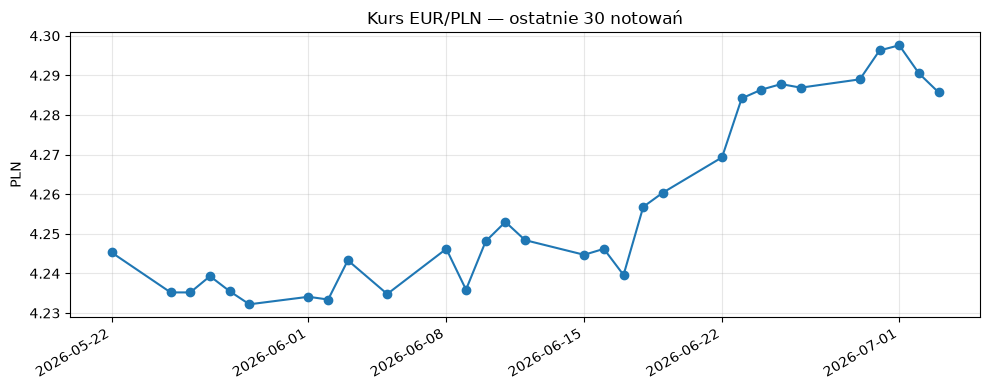

In [13]:
eur_ts = df_eur.set_index('effectiveDate')['mid']
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eur_ts.index, eur_ts.values, marker='o')
ax.set_title('Kurs EUR/PLN — ostatnie 30 notowań'); ax.set_ylabel('PLN'); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 3.5 USD i GBP — połączenie i trzy linie na jednym wykresie

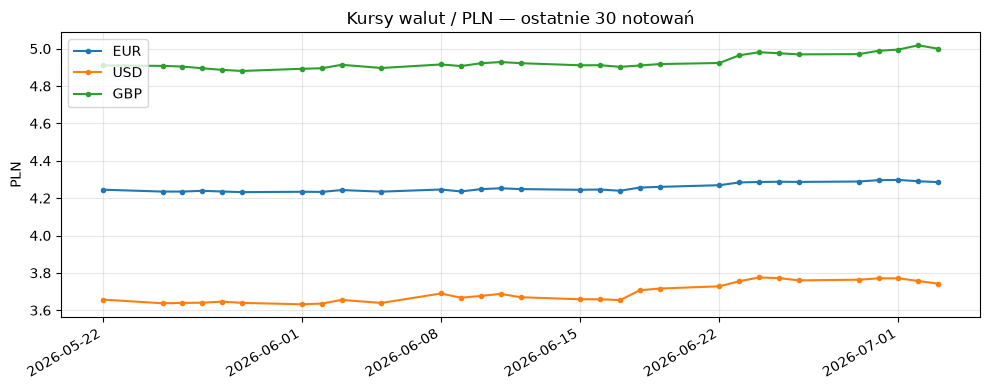

,EUR,USD,GBP
effectiveDate,,,
2026-06-29,4.2890,3.7636,4.9707
2026-06-30,4.2963,3.7708,4.9887
2026-07-01,4.2976,3.7708,4.9952
2026-07-02,4.2905,3.7568,5.0181
2026-07-03,4.2857,3.7420,4.9994


In [14]:
def kursy_last(waluta, n=30):
    u = f"https://api.nbp.pl/api/exchangerates/rates/A/{waluta}/last/{n}/?format=json"
    r = requests.get(u, timeout=15); r.raise_for_status()
    d = pd.json_normalize(r.json()['rates'])[['effectiveDate', 'mid']]
    d['effectiveDate'] = pd.to_datetime(d['effectiveDate'])
    return d.set_index('effectiveDate')['mid'].rename(waluta)

waluty = pd.concat([kursy_last('EUR'), kursy_last('USD'), kursy_last('GBP')], axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
for kol in waluty.columns:
    ax.plot(waluty.index, waluty[kol], marker='.', label=kol)
ax.set_title('Kursy walut / PLN — ostatnie 30 notowań'); ax.set_ylabel('PLN')
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout(); plt.show()
waluty.tail()

### 3.6 Zapis wyniku jako Parquet

In [15]:
waluty.to_parquet('kursy_walut.parquet')
print("Zapisano kursy_walut.parquet, rozmiar:", os.path.getsize('kursy_walut.parquet'), "B")

Zapisano kursy_walut.parquet, rozmiar: 4145 B


### 3.7 Dodatkowe — cały 2024 rok, kiedy EUR był najdroższy?
API NBP ogranicza zapytanie do **93 dni**, więc pobieramy rok w kilku fragmentach.

In [16]:
import datetime as dt

def kursy_zakres(waluta, start, end):
    s, e = dt.date.fromisoformat(start), dt.date.fromisoformat(end)
    frames, cur = [], s
    while cur <= e:
        chunk_end = min(cur + dt.timedelta(days=89), e)
        u = f"https://api.nbp.pl/api/exchangerates/rates/A/{waluta}/{cur}/{chunk_end}/?format=json"
        r = requests.get(u, timeout=15)
        if r.status_code == 200:
            frames.append(pd.DataFrame(r.json()['rates']))
        cur = chunk_end + dt.timedelta(days=1)
    df = pd.concat(frames, ignore_index=True)
    df['effectiveDate'] = pd.to_datetime(df['effectiveDate'])
    return df

eur_2024 = kursy_zakres('EUR', '2024-01-01', '2024-12-31')
najdrozszy = eur_2024.loc[eur_2024['mid'].idxmax()]
print("Notowań w 2024:", len(eur_2024))
print("EUR najdroższy dnia %s: %.4f PLN" % (najdrozszy['effectiveDate'].date(), najdrozszy['mid']))

Notowań w 2024: 252
EUR najdroższy dnia 2024-01-18: 4.4016 PLN


## Ćwiczenie 4 — Benchmark formatów
Plik `pomiary.csv` (~91 tys. wierszy). Porównanie: CSV / JSON / Parquet / HDF5 / Pickle.

In [17]:
pomiary = pd.read_csv(find_file('pomiary.csv'))
print("Kształt:", pomiary.shape)
pomiary.head(3)

Kształt: (91350, 10)


,station_id,city,date,pm25,pm10,no2,o3,temp,humidity,wind_speed
0,PL0001,Katowice,2020-01-01,23.76,34.59,46.28,154.55,13.3,82.7,3.49
1,PL0001,Katowice,2020-01-02,4.28,7.02,7.75,95.93,16.2,31.0,4.24
2,PL0001,Katowice,2020-01-03,3.78,36.25,30.14,39.14,18.3,67.9,3.87


In [18]:
# Zapis w różnych formatach (HDF5 wymaga pakietu 'tables' — na Colab: !pip install tables)
pomiary.to_json('pomiary.json', orient='records')
pomiary.to_parquet('pomiary.parquet')
pomiary.to_pickle('pomiary.pkl')
hdf5_ok = True
try:
    pomiary.to_hdf('pomiary.h5', key='dane', mode='w')  # key jako keyword (pandas 2.x i 3.x)
except ImportError:
    hdf5_ok = False
    print("Pominięto HDF5 — brak pakietu 'tables' (zainstaluj: !pip install tables)")
print("Zapisano formaty.", "HDF5 OK" if hdf5_ok else "bez HDF5")

Zapisano formaty. HDF5 OK


{'CSV': 5.86, 'JSON': 14.4, 'Parquet': 1.29, 'Pickle': 9.47, 'HDF5': 12.0} MB


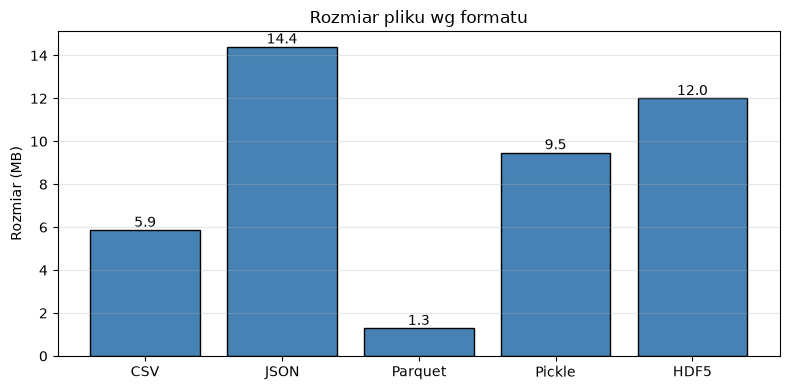

In [19]:
# Rozmiary plików na dysku
pliki = {'CSV': find_file('pomiary.csv'), 'JSON': 'pomiary.json',
         'Parquet': 'pomiary.parquet', 'Pickle': 'pomiary.pkl'}
if hdf5_ok:
    pliki['HDF5'] = 'pomiary.h5'
rozmiary = {k: os.path.getsize(v) / 1e6 for k, v in pliki.items()}
print({k: round(v, 2) for k, v in rozmiary.items()}, "MB")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rozmiary.keys(), rozmiary.values(), color='steelblue', edgecolor='black')
ax.set_ylabel('Rozmiar (MB)'); ax.set_title('Rozmiar pliku wg formatu'); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(rozmiary.values()):
    ax.annotate(f"{v:.1f}", (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()

{'CSV': 0.0882, 'JSON': 0.264, 'Parquet': 0.0134, 'Pickle': 0.0096, 'HDF5': 0.0533} s


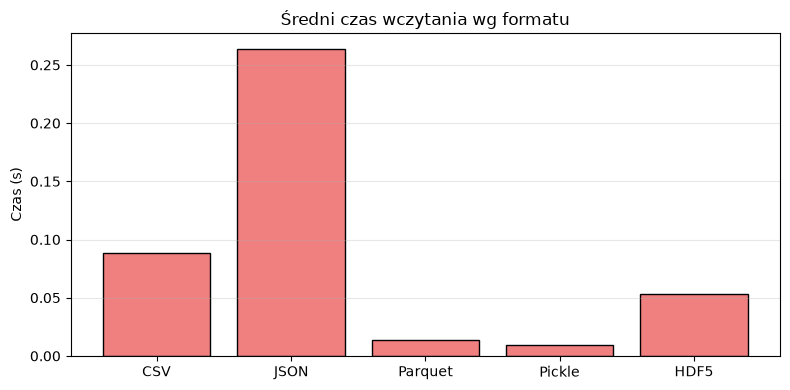

In [20]:
# Czas wczytywania każdego formatu
def czas_odczytu(func, path, n=3):
    t = time.perf_counter()
    for _ in range(n):
        func(path)
    return (time.perf_counter() - t) / n

czasy = {
    'CSV': czas_odczytu(pd.read_csv, find_file('pomiary.csv')),
    'JSON': czas_odczytu(lambda p: pd.read_json(p), 'pomiary.json'),
    'Parquet': czas_odczytu(pd.read_parquet, 'pomiary.parquet'),
    'Pickle': czas_odczytu(pd.read_pickle, 'pomiary.pkl'),
}
if hdf5_ok:
    czasy['HDF5'] = czas_odczytu(lambda p: pd.read_hdf(p, key='dane'), 'pomiary.h5')
print({k: round(v, 4) for k, v in czasy.items()}, "s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(czasy.keys(), czasy.values(), color='lightcoral', edgecolor='black')
ax.set_ylabel('Czas (s)'); ax.set_title('Średni czas wczytania wg formatu'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:
# Wczytanie tylko 2 kolumn z Parquet vs wszystkich
t = time.perf_counter(); pd.read_parquet('pomiary.parquet'); t_all = time.perf_counter() - t
t = time.perf_counter(); pd.read_parquet('pomiary.parquet', columns=['date', 'pm25']); t_2 = time.perf_counter() - t
print("Parquet wszystkie kolumny: %.4f s" % t_all)
print("Parquet 2 kolumny:         %.4f s  (Parquet jest kolumnowy → czyta tylko potrzebne dane)" % t_2)

Parquet wszystkie kolumny: 0.0060 s
Parquet 2 kolumny:         0.0049 s  (Parquet jest kolumnowy → czyta tylko potrzebne dane)


### Wnioski (Ćwiczenie 4)
- **Najmniejszy rozmiar:** Parquet (kompresja kolumnowa) — dużo mniejszy niż CSV; JSON jest największy.
- **Najszybszy odczyt:** Pickle/Parquet; JSON i CSV są wolne (parsowanie tekstu).
- **Parquet czyta wybrane kolumny** bez wczytywania całości → ogromna przewaga przy szerokich danych.
- **Do długoterminowego przechowywania:** **Parquet** — mały, przenośny, typowany, wspierany wszędzie.
- **Do szybkich analiz w Pythonie:** **Parquet** (lub Pickle, ale Pickle jest wersjozależny i niebezpieczny
  przy niezaufanych źródłach).

## Ćwiczenie 5 — SQLite i pandas
Plik `sklep.db`: tabele `klienci` (200), `produkty` (15), `zamowienia` (1000).

### 5.1 Połączenie i lista tabel (`sqlite_master`)

In [22]:
con = sqlite3.connect(find_file('sklep.db'))
tabele = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print("Tabele w bazie:", tabele['name'].tolist())

Tabele w bazie: ['klienci', 'produkty', 'zamowienia']


### 5.2 Wczytanie każdej tabeli — rozmiary i typy

In [23]:
df_klienci = pd.read_sql("SELECT * FROM klienci", con)
df_produkty = pd.read_sql("SELECT * FROM produkty", con)
df_zamowienia = pd.read_sql("SELECT * FROM zamowienia", con)
for nazwa, d in [('klienci', df_klienci), ('produkty', df_produkty), ('zamowienia', df_zamowienia)]:
    print(f"{nazwa}: shape={d.shape}")
    print(d.dtypes.to_dict())
    print()

klienci: shape=(200, 6)
{'id': dtype('int64'), 'imie': <StringDtype(na_value=nan)>, 'nazwisko': <StringDtype(na_value=nan)>, 'miasto': <StringDtype(na_value=nan)>, 'wiek': dtype('int64'), 'data_rejestracji': <StringDtype(na_value=nan)>}

produkty: shape=(15, 4)
{'id': dtype('int64'), 'nazwa': <StringDtype(na_value=nan)>, 'kategoria': <StringDtype(na_value=nan)>, 'cena': dtype('float64')}

zamowienia: shape=(1000, 5)
{'id': dtype('int64'), 'klient_id': dtype('int64'), 'produkt_id': dtype('int64'), 'ilosc': dtype('int64'), 'data_zamowienia': <StringDtype(na_value=nan)>}



### 5.3 SQL — 10 klientów z największą liczbą zamówień

In [24]:
zapytanie = '''
SELECT k.id, k.imie, k.nazwisko, COUNT(z.id) AS liczba_zamowien
FROM klienci k
JOIN zamowienia z ON z.klient_id = k.id
GROUP BY k.id
ORDER BY liczba_zamowien DESC
LIMIT 10
'''
top10 = pd.read_sql(zapytanie, con)
display(top10)

,id,imie,nazwisko,liczba_zamowien
0,174,Piotr,Wójcik,10
1,170,Grażyna,Woźniak,10
2,72,Michał,Woźniak,10
3,166,Adam,Kamiński,9
4,164,Tomasz,Wiśniewski,9
5,163,Damian,Kowalski,9
6,147,Maria,Woźniak,9
7,138,Michał,Kozłowski,9
8,102,Filip,Kowalczyk,9
9,99,Bartek,Woźniak,9


### Dodatkowe 1 — `chunksize`: wczytywanie `zamowienia` porcjami po 100

In [25]:
liczba_porcji = 0
suma_wierszy = 0
for chunk in pd.read_sql("SELECT * FROM zamowienia", con, chunksize=100):
    liczba_porcji += 1
    suma_wierszy += len(chunk)
print(f"Wczytano {suma_wierszy} wierszy w {liczba_porcji} porcjach po 100")

Wczytano 1000 wierszy w 10 porcjach po 100


### Dodatkowe 2 — SQL: sumaryczna wartość sprzedaży per kategoria

In [26]:
zapytanie2 = '''
SELECT p.kategoria, ROUND(SUM(z.ilosc * p.cena), 2) AS wartosc_sprzedazy
FROM zamowienia z
JOIN produkty p ON p.id = z.produkt_id
GROUP BY p.kategoria
ORDER BY wartosc_sprzedazy DESC
'''
sprzedaz_sql = pd.read_sql(zapytanie2, con)
display(sprzedaz_sql)

,kategoria,wartosc_sprzedazy
0,Elektronika,1069390.0
1,Edukacja,84331.0
2,Akcesoria,60495.0
3,Książki,39083.0
4,Biuro,11625.0


### Dodatkowe 3 — To samo w pandas + porównanie czytelności

In [27]:
# Wersja pandas: merge + groupby
polaczone = df_zamowienia.merge(df_produkty, left_on='produkt_id', right_on='id', suffixes=('', '_prod'))
polaczone['wartosc'] = polaczone['ilosc'] * polaczone['cena']
sprzedaz_pandas = (polaczone.groupby('kategoria')['wartosc'].sum()
                   .round(2).sort_values(ascending=False).reset_index())
display(sprzedaz_pandas)

print("Wnioski o czytelności:")
print("- SQL: zwięzły dla agregacji z JOIN — deklaratywny, blisko 'co chcę policzyć'.")
print("- pandas: bardziej rozwlekły (merge + kolumna pomocnicza + groupby), ale łatwiej")
print("  wpleść w dalszy pipeline analityczny/wizualizacje w Pythonie.")
con.close()

,kategoria,wartosc
0,Elektronika,1069390.0
1,Edukacja,84331.0
2,Akcesoria,60495.0
3,Książki,39083.0
4,Biuro,11625.0


Wnioski o czytelności:
- SQL: zwięzły dla agregacji z JOIN — deklaratywny, blisko 'co chcę policzyć'.
- pandas: bardziej rozwlekły (merge + kolumna pomocnicza + groupby), ale łatwiej
  wpleść w dalszy pipeline analityczny/wizualizacje w Pythonie.
